In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Loaded")

Libraries Loaded


In [2]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


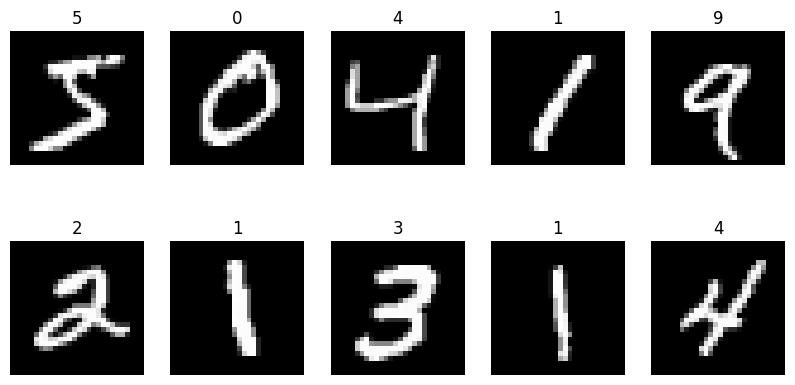

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Normalization Complete")

Normalization Complete


In [5]:
X_train = X_train.reshape(
    -1,28,28,1
)

X_test = X_test.reshape(
    -1,28,28,1
)

print(X_train.shape)

(60000, 28, 28, 1)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

model = Sequential([
    
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(28,28,1)
    ),
    
    MaxPooling2D((2,2)),
    
    Flatten(),
    
    Dense(
        128,
        activation="relu"
    ),
    
    Dense(
        10,
        activation="softmax"
    )
])

print("Model Created")

Model Created


c:\Users\VIVEKVIPPARLA\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled")

Model Compiled


In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test,y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9540 - loss: 0.1517 - val_accuracy: 0.9813 - val_loss: 0.0549
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9842 - loss: 0.0519 - val_accuracy: 0.9851 - val_loss: 0.0434
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9897 - loss: 0.0326 - val_accuracy: 0.9866 - val_loss: 0.0391
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9931 - loss: 0.0218 - val_accuracy: 0.9875 - val_loss: 0.0430
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9955 - loss: 0.0140 - val_accuracy: 0.9878 - val_loss: 0.0404


In [9]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9878 - loss: 0.0404
Test Accuracy: 0.9878000020980835


In [10]:
predictions = model.predict(X_test)

print(predictions[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[2.1421700e-09 6.1491146e-10 3.2435048e-07 8.8474269e-07 6.7908193e-11
 3.2891710e-12 6.5753155e-14 9.9999833e-01 2.2361695e-07 2.1577570e-07]


In [11]:
predicted_digit = np.argmax(
    predictions[0]
)

print(
    "Predicted Digit:",
    predicted_digit
)

print(
    "Actual Digit:",
    y_test[0]
)

Predicted Digit: 7
Actual Digit: 7


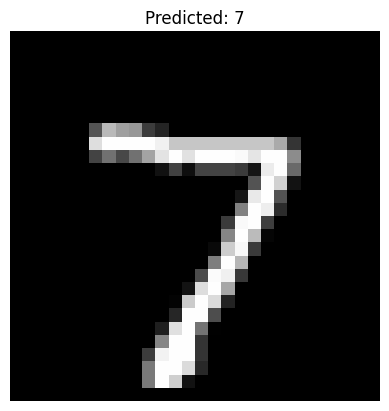

In [12]:
plt.imshow(
    X_test[0].reshape(28,28),
    cmap="gray"
)

plt.title(
    f"Predicted: {predicted_digit}"
)

plt.axis("off")

plt.show()

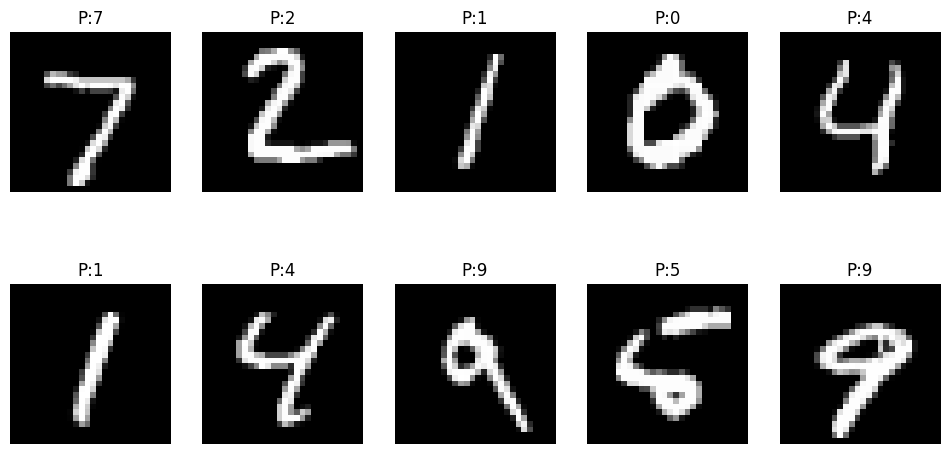

In [13]:
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap="gray"
    )

    predicted = np.argmax(
        predictions[i]
    )

    plt.title(
        f"P:{predicted}"
    )

    plt.axis("off")

plt.show()

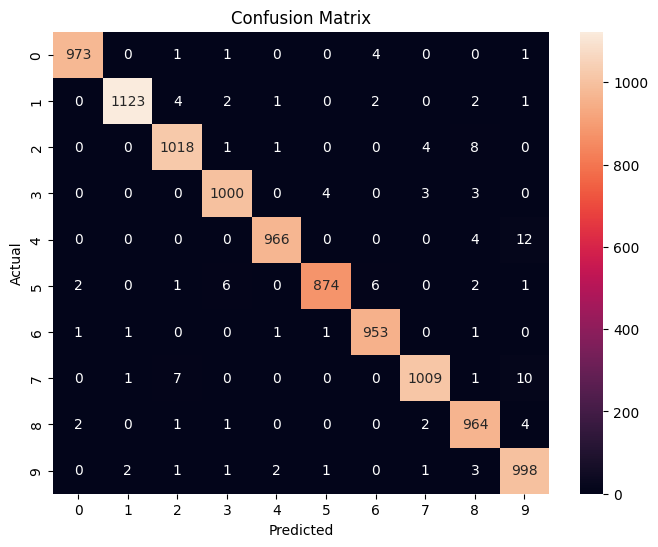

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

predicted_classes = np.argmax(
    predictions,
    axis=1
)

cm = confusion_matrix(
    y_test,
    predicted_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

In [15]:
model.save(
    "handwritten_model.h5"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully


# Conclusion

A Convolutional Neural Network (CNN) was developed to recognize handwritten digits using the MNIST dataset.

The model was trained on 60,000 images and tested on 10,000 images.

The CNN achieved high accuracy in identifying handwritten digits from 0 to 9.

The trained model was saved as handwritten_model.h5 for future predictions.

# Project Summary

Dataset: MNIST Handwritten Digits

Deep Learning Model:
- Convolutional Neural Network (CNN)

Tasks Completed:
- Data Loading
- Data Preprocessing
- Image Normalization
- CNN Model Development
- Model Training
- Model Evaluation
- Digit Prediction
- Confusion Matrix
- Model Saving